In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
def simulate_battery_data(n_steps=500, n_cells=10):
    np.random.seed(42)
    data = []

    for t in range(n_steps):
        current = np.random.uniform(5, 50)

        voltages = np.random.normal(3.7, 0.02, n_cells)
        temps = np.random.normal(30, 2, n_cells)

        # Internal Short Circuit
        if 100 < t < 150:
            voltages[2] -= 0.01 * (t - 100)

        # Temperature Spike
        if t == 250:
            temps[4] += 60

        # Loose Connection
        if 350 < t < 400 and current > 40:
            voltages[6] += np.random.choice([-0.3, 0.3])

        row = {"time": t, "current": current}

        for i in range(n_cells):
            row[f"V{i}"] = voltages[i]
            row[f"T{i}"] = temps[i]

        data.append(row)

    return pd.DataFrame(data)

df = simulate_battery_data()
df.head()

,time,current,V0,T0,V1,T1,V2,T2,V3,T3,...,V5,T5,V6,T6,V7,T7,V8,T8,V9,T9
0,0,21.854305,3.677762,31.632890,3.706378,26.952248,3.705581,29.143908,3.720210,28.515186,...,3.689497,25.720759,3.688572,28.741050,3.681518,31.195441,3.647749,35.118976,3.719007,30.788466
1,1,7.090269,3.676980,30.417727,3.707514,26.080660,3.687987,27.343628,3.694166,30.393722,...,3.737046,30.342737,3.699730,29.768703,3.678846,29.397793,3.716451,27.042956,3.675583,28.560312
2,2,42.293188,3.673066,26.983693,3.682388,32.199294,3.677389,29.644536,3.702689,29.179233,...,3.717755,28.203584,3.717887,31.669591,3.715100,30.593123,3.695857,27.924340,3.687530,29.848393
3,3,37.096015,3.707228,29.560656,3.730761,30.714225,3.699283,32.955788,3.731293,28.963460,...,3.716438,28.996486,3.701741,31.830804,3.694020,30.657502,3.701835,28.940480,3.660249,31.026535
4,4,45.165155,3.727437,29.208967,3.703511,29.421726,3.693814,30.905873,3.713463,29.667878,...,3.692643,25.955370,3.725475,28.113886,3.694161,32.807917,3.646896,29.962898,3.706910,26.652991


In [4]:
# feature engineering

def preprocess(df, n_cells=10):
    voltage_cols = [f"V{i}" for i in range(n_cells)]
    temp_cols = [f"T{i}" for i in range(n_cells)]

    df["pack_mean"] = df[voltage_cols].mean(axis=1)

    # Voltage deviation
    for col in voltage_cols:
        df[f"{col}_dev"] = df[col] - df["pack_mean"]

    # Temperature rate of change
    for col in temp_cols:
        df[f"{col}_roc"] = df[col].diff().fillna(0)

    return df

df = preprocess(df)
df.head()

,time,current,V0,T0,V1,T1,V2,T2,V3,T3,...,T0_roc,T1_roc,T2_roc,T3_roc,T4_roc,T5_roc,T6_roc,T7_roc,T8_roc,T9_roc
0,0,21.854305,3.677762,31.632890,3.706378,26.952248,3.705581,29.143908,3.720210,28.515186,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,7.090269,3.676980,30.417727,3.707514,26.080660,3.687987,27.343628,3.694166,30.393722,...,-1.215163,-0.871588,-1.800280,1.878536,2.883621,4.621978,1.027653,-1.797648,-8.076020,-2.228154
2,2,42.293188,3.673066,26.983693,3.682388,32.199294,3.677389,29.644536,3.702689,29.179233,...,-3.434034,6.118634,2.300908,-1.214489,0.882500,-2.139152,1.900887,1.195330,0.881384,1.288081
3,3,37.096015,3.707228,29.560656,3.730761,30.714225,3.699283,32.955788,3.731293,28.963460,...,2.576963,-1.485069,3.311252,-0.215774,-3.976420,0.792902,0.161213,0.064379,1.016139,1.178142
4,4,45.165155,3.727437,29.208967,3.703511,29.421726,3.693814,30.905873,3.713463,29.667878,...,-0.351689,-1.292499,-2.049915,0.704419,2.046865,-3.041116,-3.716918,2.150415,1.022419,-4.373544


In [5]:
# train isolation forest

def train_model(df):
    features = [c for c in df.columns if "dev" in c or "roc" in c]

    model = IsolationForest(contamination=0.03, random_state=42)
    df["anomaly"] = model.fit_predict(df[features])

    return df

df = train_model(df)

df["anomaly"].value_counts()

anomaly
 1    485
-1     15
Name: count, dtype: int64

In [6]:
def root_cause(row):
    if max([abs(row[c]) for c in row.index if "roc" in c]) > 20:
        return "Temperature Spike", "Thermal Management Override"

    if max([abs(row[c]) for c in row.index if "dev" in c]) > 0.2:
        return "High Voltage Variance", "Active Balancing"

    if min([row[c] for c in row.index if "dev" in c]) < -0.1:
        return "Voltage Drop", "Limp Home Mode"

    return "Erratic Signal Spikes", "Check physical connections; Use redundant averaging"

In [7]:
class BatteryMedic:
    def diagnose(self, row):
        if row["anomaly"] == -1:
            fault, action = root_cause(row)

            if fault in ["Temperature Spike", "Voltage Drop"]:
                severity = "High"
            elif fault == "High Voltage Variance":
                severity = "Medium"
            else:
                severity = "Low"

            return {
                "Status": "Anomaly Detected",
                "Fault_Type": fault,
                "Severity": severity,
                "Action_Required": action
            }
        return None

In [8]:
medic = BatteryMedic()

reports = []

for _, row in df.iterrows():
    result = medic.diagnose(row)
    if result:
        reports.append(result)

print("===== DIAGNOSTIC REPORT =====\n")

for r in reports[:10]:
    print(r)

===== DIAGNOSTIC REPORT =====

{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High Voltage Variance', 'Severity': 'Medium', 'Action_Required': 'Active Balancing'}
{'Status': 'Anomaly Detected', 'Fault_Type': 'High V

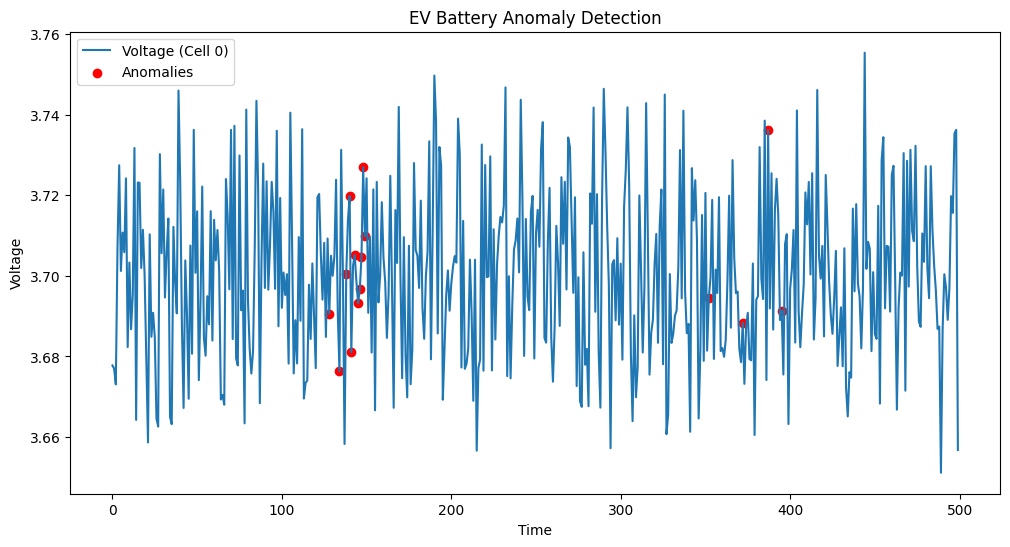

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df["time"], df["V0"], label="Voltage (Cell 0)")

anomalies = df[df["anomaly"] == -1]

plt.scatter(anomalies["time"], anomalies["V0"], color='red', label="Anomalies")

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("EV Battery Anomaly Detection")
plt.legend()

plt.show()

In [10]:
import time

medic = BatteryMedic()

print("Starting Real-Time Simulation...\n")

for i in range(50):
    row = df.iloc[i]

    result = medic.diagnose(row)

    if result:
        print(f"Time {row['time']} → {result}")

    time.sleep(0.2)

Starting Real-Time Simulation...



In [11]:
print("===== DIAGNOSTIC REPORT =====")

for i in range(10):
    row = df.iloc[i]
    result = medic.diagnose(row)
    
    if result:
        print(result)

===== DIAGNOSTIC REPORT =====


In [12]:
df.to_csv("battery_data.csv", index=False)